In [9]:
from typing import TypedDict
class protofoliostate(TypedDict):
    amount_usd: float
    total_usd: float
    total_inr: float

In [10]:
def calc_total(state: protofoliostate) -> protofoliostate:
    state['total_usd'] = state['amount_usd'] * 1.08  
    return state

In [11]:
def convert_to_inr(state: protofoliostate) -> protofoliostate:
    state['total_inr'] = state['total_usd'] * 85.0  
    return state

In [12]:
from langgraph.graph import StateGraph, START, END
builder = StateGraph(protofoliostate)
builder.add_node("calc_total", calc_total)
builder.add_node("convert_to_inr", convert_to_inr)
builder.add_edge(START, "calc_total")
builder.add_edge("calc_total", "convert_to_inr")
builder.add_edge("convert_to_inr", END)
graph = builder.compile()

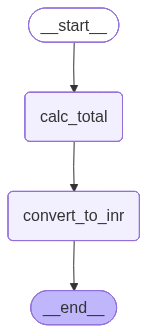

In [13]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
graph.invoke({"amount_usd": 1000.0})

{'amount_usd': 1000.0, 'total_usd': 1080.0, 'total_inr': 91800.0}